In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
data6 = r"C:\Users\rajeshkumar.t\Desktop\ML\Prodcict_details.csv"
df = pd.read_csv(data6)

In [4]:
print(df.columns)

Index(['order_item_id', 'status', 'seller_id', 'promotion_discount_adjustment',
       'price_change_adjustment', 'unit_creation_date_time', 'order_id',
       'account_id', 'bank_offer_adjustment', 'courier_name',
       'deliver_date_time', 'new_customer_flag', 'cancel_date_time',
       'return_completed_date_time', 'listing_price', 'product_title',
       'promise_breach', 'analytic_business_unit', 'analytic_category',
       'analytic_vertical', 'city_tier', 'cms_vertical'],
      dtype='object')


ROC-AUC: 0.6955
F1-score:0.1324


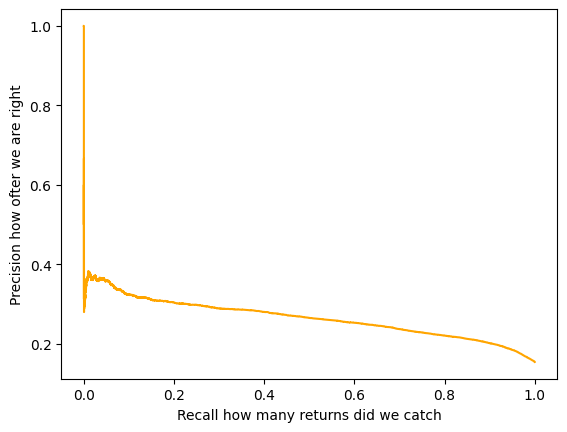

In [8]:
df['is_returned'] = df['return_completed_date_time'].notnull().astype(int)
df['unit_creation_date_time'] = pd.to_datetime(df['unit_creation_date_time'])
df['hour_of_hour'] = df['unit_creation_date_time'].dt.hour
df['day_of_week'] = df['unit_creation_date_time'].dt.dayofweek

tier_map = {'Tier 1A':4, 'Tier 1B':3, 'Tier 2': 2, 'Tier 3': 1}
df['city_tier_val'] = df['city_tier'].map(tier_map).fillna(0)
df['breach_val'] = df['promise_breach'].apply(lambda x: 1 if x== 'Breach' else 0)
df['is_new_cust'] = df['new_customer_flag'].map({'FALSE': 0, 'TRUE': 1, False: 0, True: 1})

features = ['listing_price', 'city_tier_val', 'breach_val', 'is_new_cust', 'hour_of_hour', 'day_of_week']
X= df[features]
y= df['is_returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state= 42)

model = XGBClassifier(n_estimators= 100, max_depth = 4, learning_rate= 0.1)
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:,1]
y_pred = (y_probs >= 0.3).astype(int)

auc = roc_auc_score(y_test, y_probs)
f1 = f1_score(y_test, y_pred)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

print(f"ROC-AUC: {auc:.4f}")
print(f"F1-score:{f1:.4f}")

plt.plot(recalls, precisions, color='orange', label = 'Precision-Recall')
plt.xlabel("Recall how many returns did we catch")
plt.ylabel("Precision how ofter we are right")
plt.show("Return Prediction")
plt.show()
      
      